In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(Xtrain, _),(Xtest, _) = fashion_mnist.load_data()
print(Xtrain[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

In [3]:
Xtrain = Xtrain.astype("float32")/255
Xtest = Xtest.astype("float32")/255
Xtrain = Xtrain.reshape((-1,28,28))
Xtest = Xtest.reshape((-1,28,28))

In [4]:
noiseFactor = 0.5
XtrainNoisy = Xtrain + noiseFactor*np.random.normal(0,1,Xtrain.shape)
XtestNoisy = Xtest + noiseFactor*np.random.normal(0,1,Xtest.shape)

In [5]:
XtrainNoisy = np.clip(XtrainNoisy,0,1)
XtestNoisy = np.clip(XtestNoisy,0,1)

In [6]:
inputSequence = layers.Input(shape=(28,28))
encoded = layers.LSTM(128,activation="relu",return_state=True)(inputSequence)
encodedState = encoded[1] #hidden state
encoder = models.Model(inputSequence,encodedState)

In [8]:
latentInput = layers.Input(shape=(128,))
decoded = layers.RepeatVector(28)(latentInput)
decoded = layers.LSTM(128,activation="relu",return_sequences=True)(decoded)
decoded = layers.TimeDistributed(
    layers.Dense(28,activation="sigmoid")
)(decoded)
decoder = models.Model(latentInput,decoded)

In [9]:
autoencoder = models.Model(inputSequence,decoder(encoder(inputSequence)))
autoencoder.compile(optimizer="adam",loss="binary_crossentropy")
autoencoder.fit(XtrainNoisy,Xtrain,epochs=10,batch_size=256,validation_data=(XtestNoisy,Xtest),shuffle=True)

Epoch 1/10
235/235 [==============================] - 22s 87ms/step - loss: 0.4105 - val_loss: 0.3377
Epoch 2/10
235/235 [==============================] - 21s 88ms/step - loss: 0.3267 - val_loss: 0.3200
Epoch 3/10
235/235 [==============================] - 20s 86ms/step - loss: 0.3157 - val_loss: 0.3141
Epoch 4/10
235/235 [==============================] - 20s 86ms/step - loss: 0.3102 - val_loss: 0.3127
Epoch 5/10
235/235 [==============================] - 21s 88ms/step - loss: 0.3072 - val_loss: 0.3078
Epoch 6/10
235/235 [==============================] - 21s 88ms/step - loss: 0.3045 - val_loss: 0.3073
Epoch 7/10
235/235 [==============================] - 20s 87ms/step - loss: 0.3025 - val_loss: 0.3043
Epoch 8/10
235/235 [==============================] - 20s 87ms/step - loss: 0.3013 - val_loss: 0.3022
Epoch 9/10
235/235 [==============================] - 20s 86ms/step - loss: 0.2996 - val_loss: 0.3014
Epoch 10/10
235/235 [==============================] - 21s 88ms/step - loss: 0.298

313/313 [==============================] - 2s 7ms/step


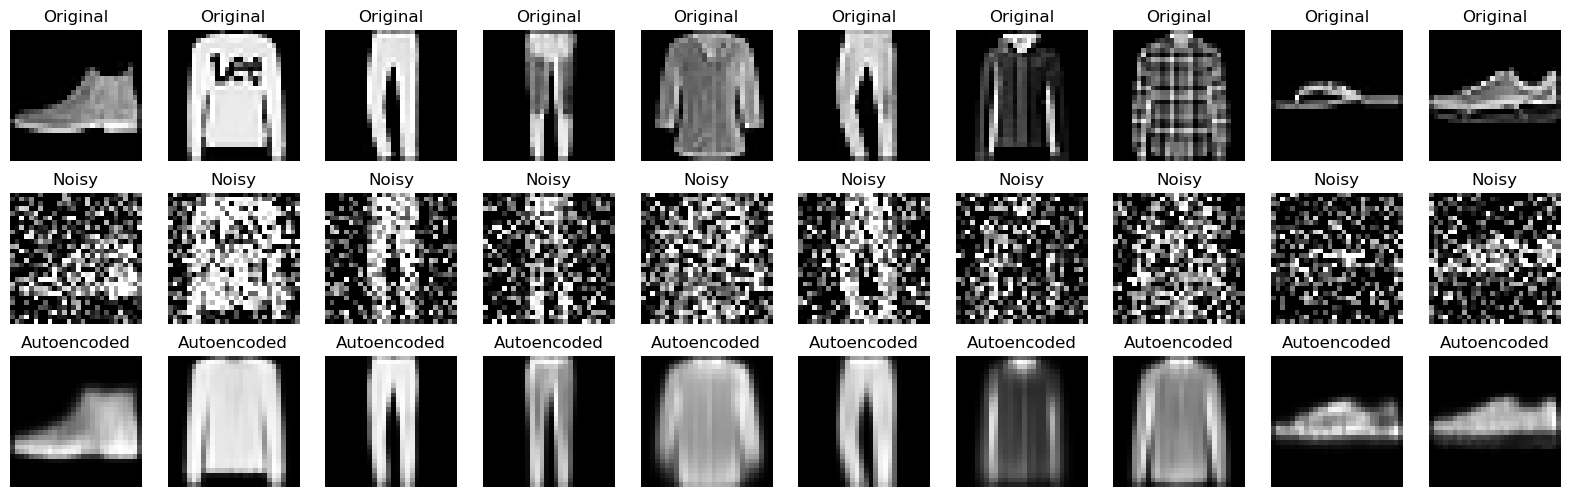

In [11]:
numImages = 10
reconImage = autoencoder.predict(XtestNoisy)
plt.figure(figsize=(20,6))
for i in range(0,numImages):
    ax = plt.subplot(3,numImages,i+1)
    plt.imshow(Xtest[i],cmap="gray")
    ax.set_title("Original")
    ax.axis("off")

    ax = plt.subplot(3,numImages,i+numImages+1)
    plt.imshow(XtestNoisy[i],cmap="gray")
    ax.set_title("Noisy")
    ax.axis("off")

    ax = plt.subplot(3,numImages,i+numImages*2+1)
    plt.imshow(reconImage[i],cmap="gray")
    ax.set_title("Autoencoded")
    ax.axis("off")

plt.show()